In [2]:
# !pip install evaluate rouge_score nltk

In [3]:
import pickle
import pandas as pd
import evaluate
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import T5Tokenizer, T5ForConditionalGeneration

c:\Models\LLM-From-Scratch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
test_df = pd.read_csv("../data/processed/test.csv")
test_df = test_df.dropna(subset=["question", "answer"])

test_df = test_df.head(50)

print(test_df.shape)
test_df.head()

(50, 2)


,question,answer
0,what is zostavax for?- consider waiting for a ...,ZOSTAVAX® is a live attenuated virus vaccine i...
1,"show spironolactone 30mg ""tab/accord"" healthcare","Spironolactone oral tablets contain 25 mg, 50 ..."
2,where is tetracycline metabolized?,The majority of first-generation tetracyclines...
3,is lasix the only diuretic drug for fluid buil...,Commonly prescribed include: Furosemide (Lasix...
4,how do steroids effect the digestive system,"teroid abuse can also be hepatotoxic, promotin..."


In [5]:
distilbert_model = SentenceTransformer("../models/distilbert_retriever/model")

with open("../models/distilbert_retriever/questions.pkl", "rb") as f:
    questions = pickle.load(f)

with open("../models/distilbert_retriever/answers.pkl", "rb") as f:
    answers = pickle.load(f)

with open("../models/distilbert_retriever/question_embeddings.pkl", "rb") as f:
    question_embeddings = pickle.load(f)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3319.45it/s]


In [6]:
t5_tokenizer = T5Tokenizer.from_pretrained("../models/t5")
t5_model = T5ForConditionalGeneration.from_pretrained("../models/t5")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 3544.03it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [7]:
def distilbert_predict(question):
    user_embedding = distilbert_model.encode([question])

    similarities = cosine_similarity(
        user_embedding,
        question_embeddings
    )[0]

    best_index = similarities.argmax()
    best_score = similarities[best_index]

    if best_score < 0.70:
        return "No reliable answer found."

    return answers[best_index]


def t5_predict(question):
    input_text = "question: " + question

    inputs = t5_tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    outputs = t5_model.generate(
        **inputs,
        max_length=128,
        num_beams=4,
        early_stopping=True
    )

    return t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

In [8]:
distilbert_predictions = []
t5_predictions = []
references = []

for _, row in test_df.iterrows():
    question = row["question"]
    reference = row["answer"]

    distilbert_predictions.append(distilbert_predict(question))
    t5_predictions.append(t5_predict(question))
    references.append(reference)

print("Tahminler oluşturuldu.")

Tahminler oluşturuldu.


In [9]:
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

distilbert_bleu = bleu.compute(
    predictions=distilbert_predictions,
    references=[[ref] for ref in references]
)

t5_bleu = bleu.compute(
    predictions=t5_predictions,
    references=[[ref] for ref in references]
)

distilbert_rouge = rouge.compute(
    predictions=distilbert_predictions,
    references=references
)

t5_rouge = rouge.compute(
    predictions=t5_predictions,
    references=references
)

print("DistilBERT BLEU:", distilbert_bleu)
print("T5 BLEU:", t5_bleu)

print("DistilBERT ROUGE:", distilbert_rouge)
print("T5 ROUGE:", t5_rouge)

DistilBERT BLEU: {'bleu': 0.011256466864486853, 'precisions': [0.3333333333333333, 0.20214669051878353, 0.20235756385068762, 0.21568627450980393], 'brevity_penalty': 0.048337063601469256, 'length_ratio': 0.24816625916870416, 'translation_length': 609, 'reference_length': 2454}
T5 BLEU: {'bleu': 0.026824332981104343, 'precisions': [0.21462639109697934, 0.04463799673380512, 0.017347509792949075, 0.010362694300518135], 'brevity_penalty': 0.7404649735037913, 'length_ratio': 0.7689486552567237, 'translation_length': 1887, 'reference_length': 2454}
DistilBERT ROUGE: {'rouge1': np.float64(0.08027865253391386), 'rouge2': np.float64(0.04674514348860245), 'rougeL': np.float64(0.07318956014287141), 'rougeLsum': np.float64(0.07484106289932682)}
T5 ROUGE: {'rouge1': np.float64(0.16044213792411888), 'rouge2': np.float64(0.041626727845574044), 'rougeL': np.float64(0.1392926507174797), 'rougeLsum': np.float64(0.14157254521436105)}


In [10]:
results_df = pd.DataFrame({
    "question": test_df["question"].tolist(),
    "reference_answer": references,
    "distilbert_answer": distilbert_predictions,
    "t5_answer": t5_predictions
})

results_df.head(10)

,question,reference_answer,distilbert_answer,t5_answer
0,what is zostavax for?- consider waiting for a ...,ZOSTAVAX® is a live attenuated virus vaccine i...,No reliable answer found.,Zostavax is a vaccine that protects against sh...
1,"show spironolactone 30mg ""tab/accord"" healthcare","Spironolactone oral tablets contain 25 mg, 50 ...",No reliable answer found.,"Spironolactone Tablets, USP are indicated for ..."
2,where is tetracycline metabolized?,The majority of first-generation tetracyclines...,Tetracyclines are readily absorbed and are bou...,Tetracycline is metabolized in the urine.
3,is lasix the only diuretic drug for fluid buil...,Commonly prescribed include: Furosemide (Lasix...,No reliable answer found.,Lasix is the only diuretic drug in a class of ...
4,how do steroids effect the digestive system,"teroid abuse can also be hepatotoxic, promotin...",Corticosteroid use was associated with increas...,The effects of steroids on the digestive syste...
5,what medicines raise blood sugar,Some medicines for conditions other than diabe...,No reliable answer found.,Blood sugar levels can be increased by medicat...
6,what is xifaxan used for,XIFAXAN is indicated for the treatment of trav...,No reliable answer found.,Xifaxan is used to treat a variety of conditio...
7,how often should you get a zoster vaccine,The Centers for Disease Control and Prevention...,The Centers for Disease Control and Prevention...,Zostavax is recommended for people 65 years of...
8,what dosage amounts does aripiprazole,The recommended starting and target dose for a...,No reliable answer found.,Aripiprazole is in a class of medications call...
9,how to take your medicine diabetes,The medicine you take will vary by your type o...,No reliable answer found.,Diarrhea is a condition in which the blood sug...


In [11]:
results_df.to_csv("../data/processed/evaluation_results.csv", index=False)

print("Evaluation sonuçları kaydedildi.")

Evaluation sonuçları kaydedildi.


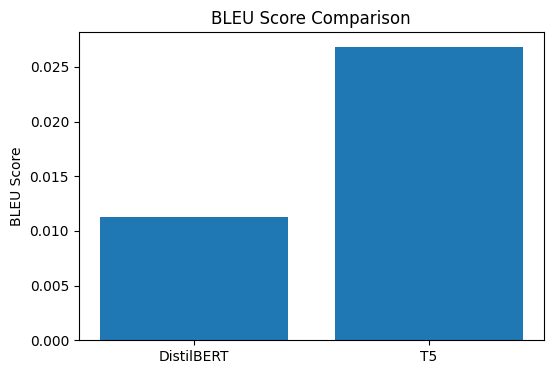

In [12]:
import matplotlib.pyplot as plt

# BLEU Grafik
models = ["DistilBERT", "T5"]

bleu_scores = [
    distilbert_bleu["bleu"],
    t5_bleu["bleu"]
]

plt.figure(figsize=(6,4))

plt.bar(models, bleu_scores)

plt.title("BLEU Score Comparison")

plt.ylabel("BLEU Score")

plt.show()

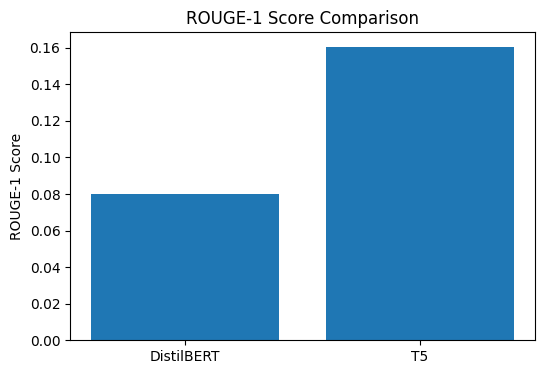

In [13]:
# ROUGE-1 Grafik
rouge1_scores = [
    distilbert_rouge["rouge1"],
    t5_rouge["rouge1"]
]

plt.figure(figsize=(6,4))

plt.bar(models, rouge1_scores)

plt.title("ROUGE-1 Score Comparison")

plt.ylabel("ROUGE-1 Score")

plt.show()

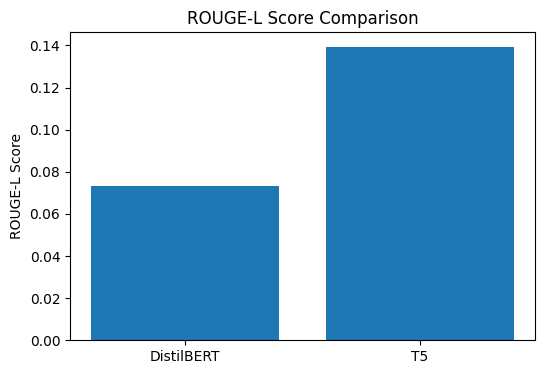

In [14]:
# ROUGE-L Grafik
rougel_scores = [
    distilbert_rouge["rougeL"],
    t5_rouge["rougeL"]
]

plt.figure(figsize=(6,4))

plt.bar(models, rougel_scores)

plt.title("ROUGE-L Score Comparison")

plt.ylabel("ROUGE-L Score")

plt.show()